# SE-CVLA PhD Thesis Demo
## Causal Graph and Counterfactual Reasoning

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import networkx as nx
import warnings
warnings.filterwarnings("ignore")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [4]:
from omegaconf import OmegaConf
from models.scm.dynamic_scm_learner import DynamicSCMLearner
cfg = OmegaConf.load("configs/model/se_cvla_10b.yaml")
model_cfg = OmegaConf.create({"encoder":{"hidden_dim":1536},"scm":cfg.scm,"policy":cfg.policy,"counterfactual":cfg.counterfactual,"uncertainty":cfg.uncertainty})
scm = DynamicSCMLearner(model_cfg).to(device)
VARS = ["Ego Speed","Ego Heading","Ego Accel","Ego Yaw Rate","Lead Vehicle","Oncoming","Pedestrian","Cyclist","Lane Pos","Curvature","Intersection","Traffic Light","Weather","Visibility","Time of Day","Road Type"]
COLORS = ["#2196F3"]*4+["#FF5722"]*4+["#4CAF50"]*4+["#9C27B0"]*4
torch.manual_seed(42)
scenarios = {"Urban Intersection":torch.randn(1,1536,device=device),"Highway Merge":torch.randn(1,1536,device=device)*1.5,"Pedestrian Crossing":torch.randn(1,1536,device=device)*0.8,"Construction Zone":torch.randn(1,1536,device=device)*1.2}
outs = {}
with torch.no_grad():
    for n,r in scenarios.items():
        o = scm(r)
        outs[n] = {"soft":o["adj_soft"].cpu().numpy(),"hard":o["adj_hard"].cpu().numpy(),"vars":o["causal_vars"].cpu().numpy()}
print(f"SCM complete for {len(outs)} scenarios")

SCM complete for 4 scenarios


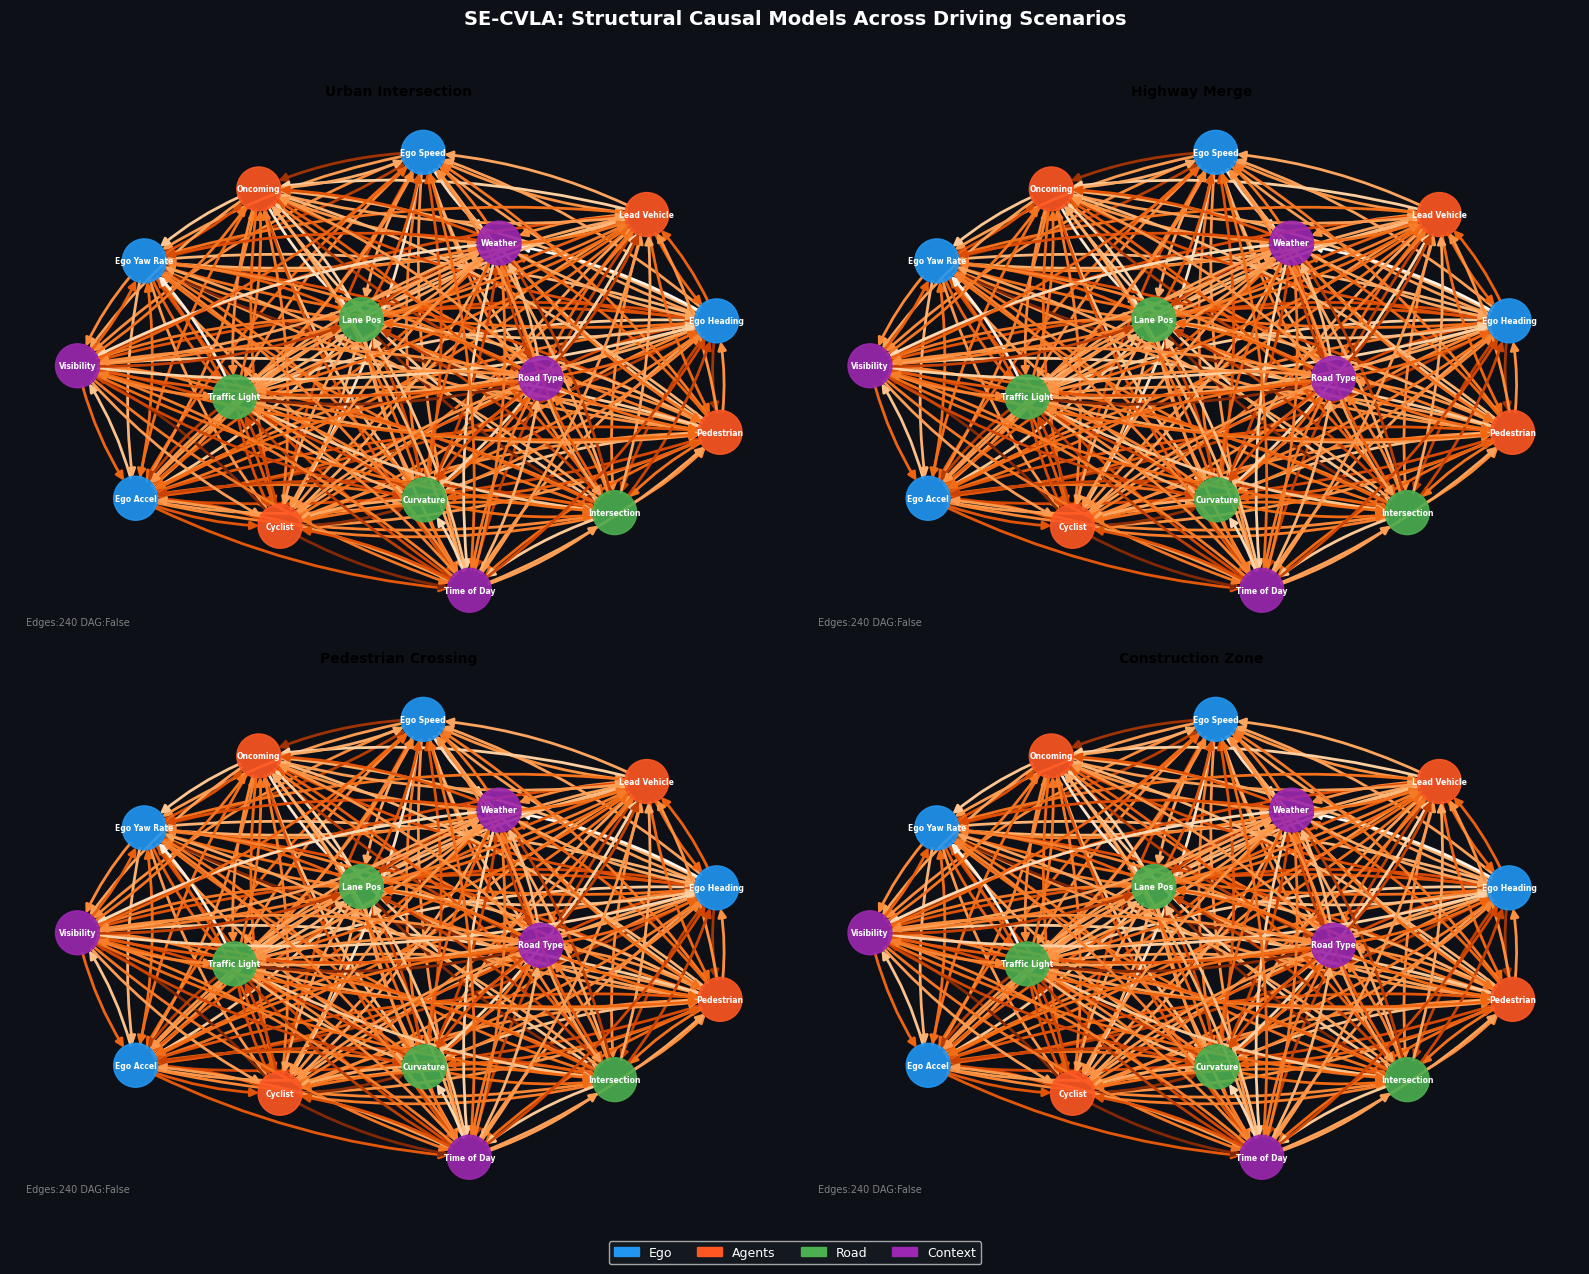

Saved: demo_causal_graphs.png


In [11]:
def draw_graph(adj, title, ax, thr=0.3):
    d = adj.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from(range(d))
    ew = []
    for i in range(d):
        for j in range(d):
            if adj[i,j]>thr and i!=j:
                G.add_edge(j,i,weight=float(adj[i,j]))
                ew.append(float(adj[i,j]))
    pos = nx.spring_layout(G, seed=42, k=2.5)
    nx.draw_networkx_nodes(G,pos,ax=ax,node_color=COLORS[:d],node_size=1000,alpha=0.9)
    short_labels = {i: VARS[i] for i in range(d)}
    nx.draw_networkx_labels(G,pos,ax=ax,labels=short_labels,font_size=5.5,font_color="white",font_weight="bold")
    if ew:
        nx.draw_networkx_edges(G,pos,ax=ax,edge_color=ew,edge_cmap=plt.cm.Oranges,width=2,arrows=True,arrowsize=12,connectionstyle="arc3,rad=0.1",min_source_margin=15,min_target_margin=15)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.axis("off")
    is_dag = nx.is_directed_acyclic_graph(G)
    ax.text(0.02,0.02,f"Edges:{G.number_of_edges()} DAG:{is_dag}",transform=ax.transAxes,fontsize=7,color="gray")

fig,axes = plt.subplots(2,2,figsize=(16,13))
fig.patch.set_facecolor("#0D1117")
fig.suptitle("SE-CVLA: Structural Causal Models Across Driving Scenarios", fontsize=14, fontweight="bold", color="white")
for ax,(name,o) in zip(axes.flatten(),outs.items()):
    ax.set_facecolor("#161B22")
    draw_graph(o["soft"],name,ax)
leg = [mpatches.Patch(color=c,label=l) for c,l in zip(["#2196F3","#FF5722","#4CAF50","#9C27B0"],["Ego","Agents","Road","Context"])]
fig.legend(handles=leg,loc="lower center",ncol=4,facecolor="#161B22",labelcolor="white",fontsize=9,bbox_to_anchor=(0.5,0.01))
plt.tight_layout(rect=[0,0.05,1,0.96])
plt.savefig("demo_causal_graphs.png",dpi=150,bbox_inches="tight",facecolor="#0D1117")
plt.show()
print("Saved: demo_causal_graphs.png")

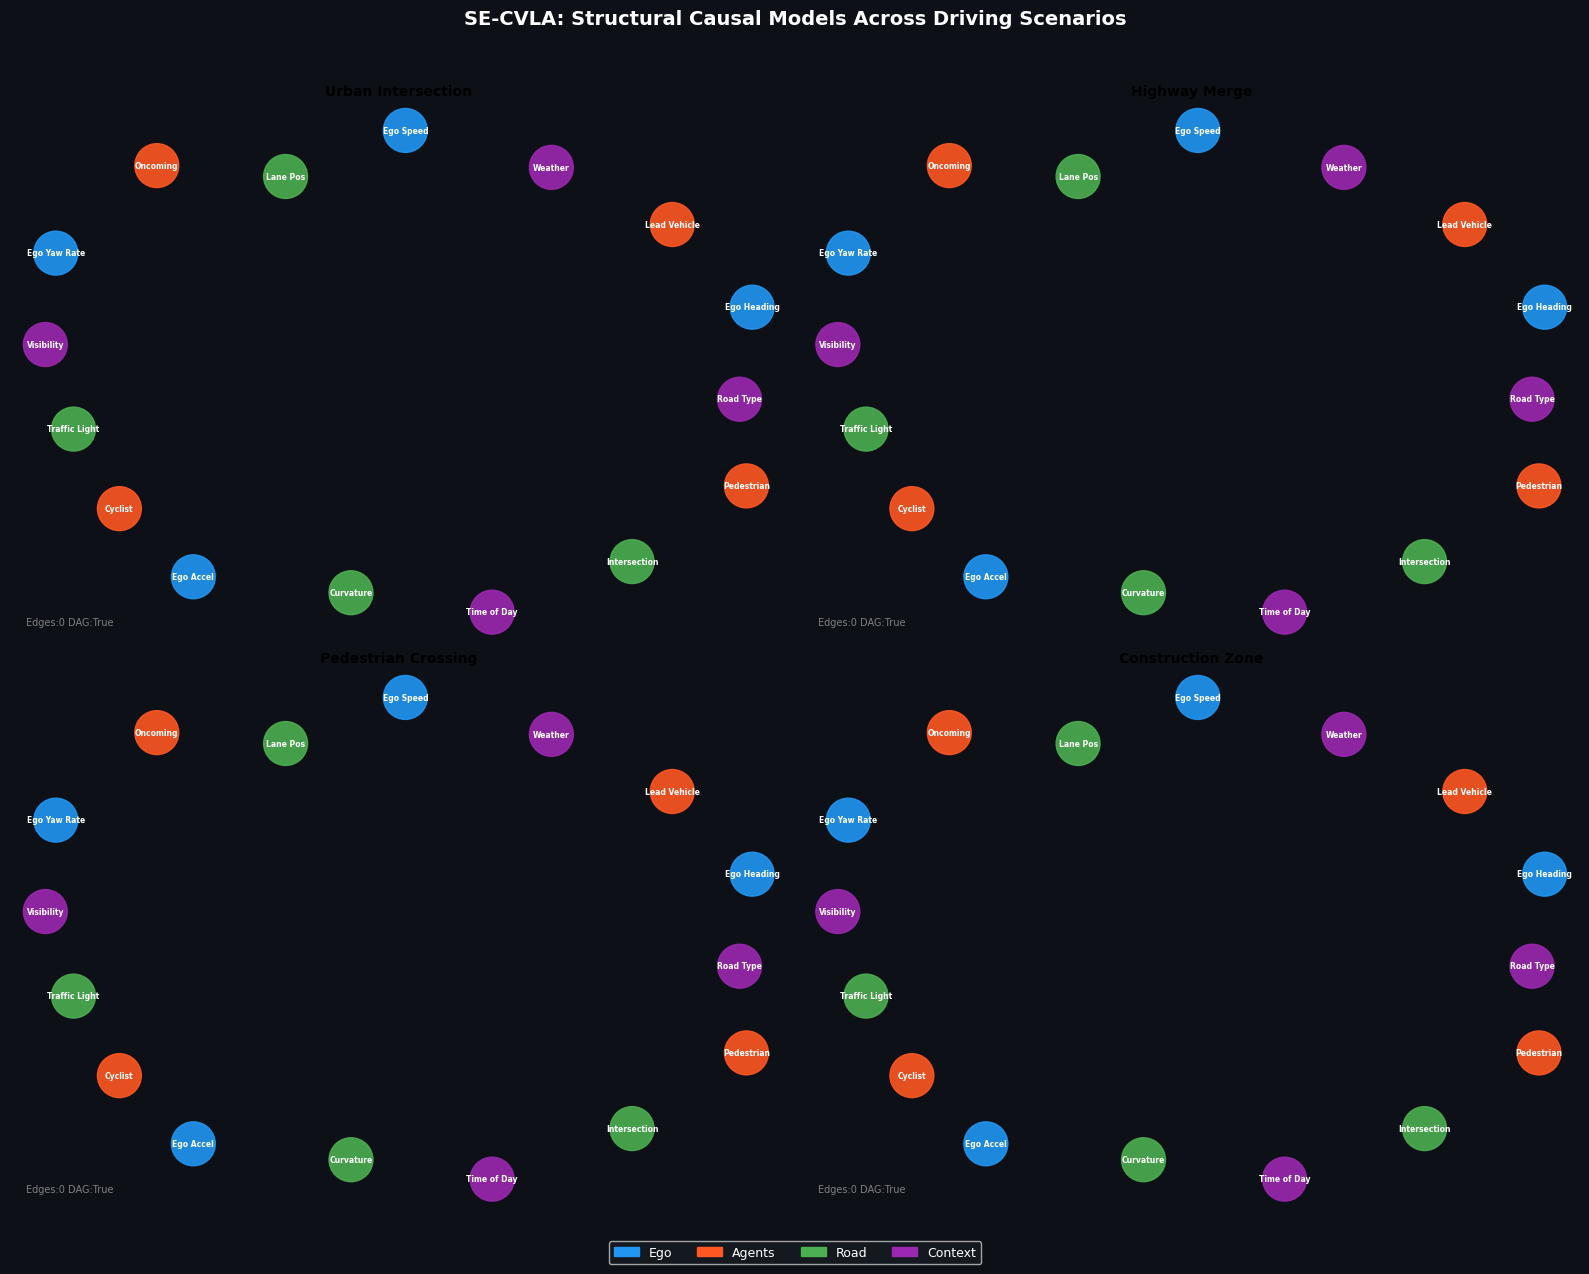

Saved: demo_causal_graphs_clean.png


In [13]:
# Re-plot with higher threshold for cleaner thesis presentation
fig,axes = plt.subplots(2,2,figsize=(16,13))
fig.patch.set_facecolor("#0D1117")
fig.suptitle("SE-CVLA: Structural Causal Models Across Driving Scenarios", fontsize=14, fontweight="bold", color="white")
for ax,(name,o) in zip(axes.flatten(),outs.items()):
    ax.set_facecolor("#161B22")
    draw_graph(o["soft"], name, ax, thr=0.6)  # higher threshold = cleaner graph
leg = [mpatches.Patch(color=c,label=l) for c,l in zip(["#2196F3","#FF5722","#4CAF50","#9C27B0"],["Ego","Agents","Road","Context"])]
fig.legend(handles=leg,loc="lower center",ncol=4,facecolor="#161B22",labelcolor="white",fontsize=9,bbox_to_anchor=(0.5,0.01))
plt.tight_layout(rect=[0,0.05,1,0.96])
plt.savefig("demo_causal_graphs_clean.png",dpi=150,bbox_inches="tight",facecolor="#0D1117")
plt.show()
print("Saved: demo_causal_graphs_clean.png")

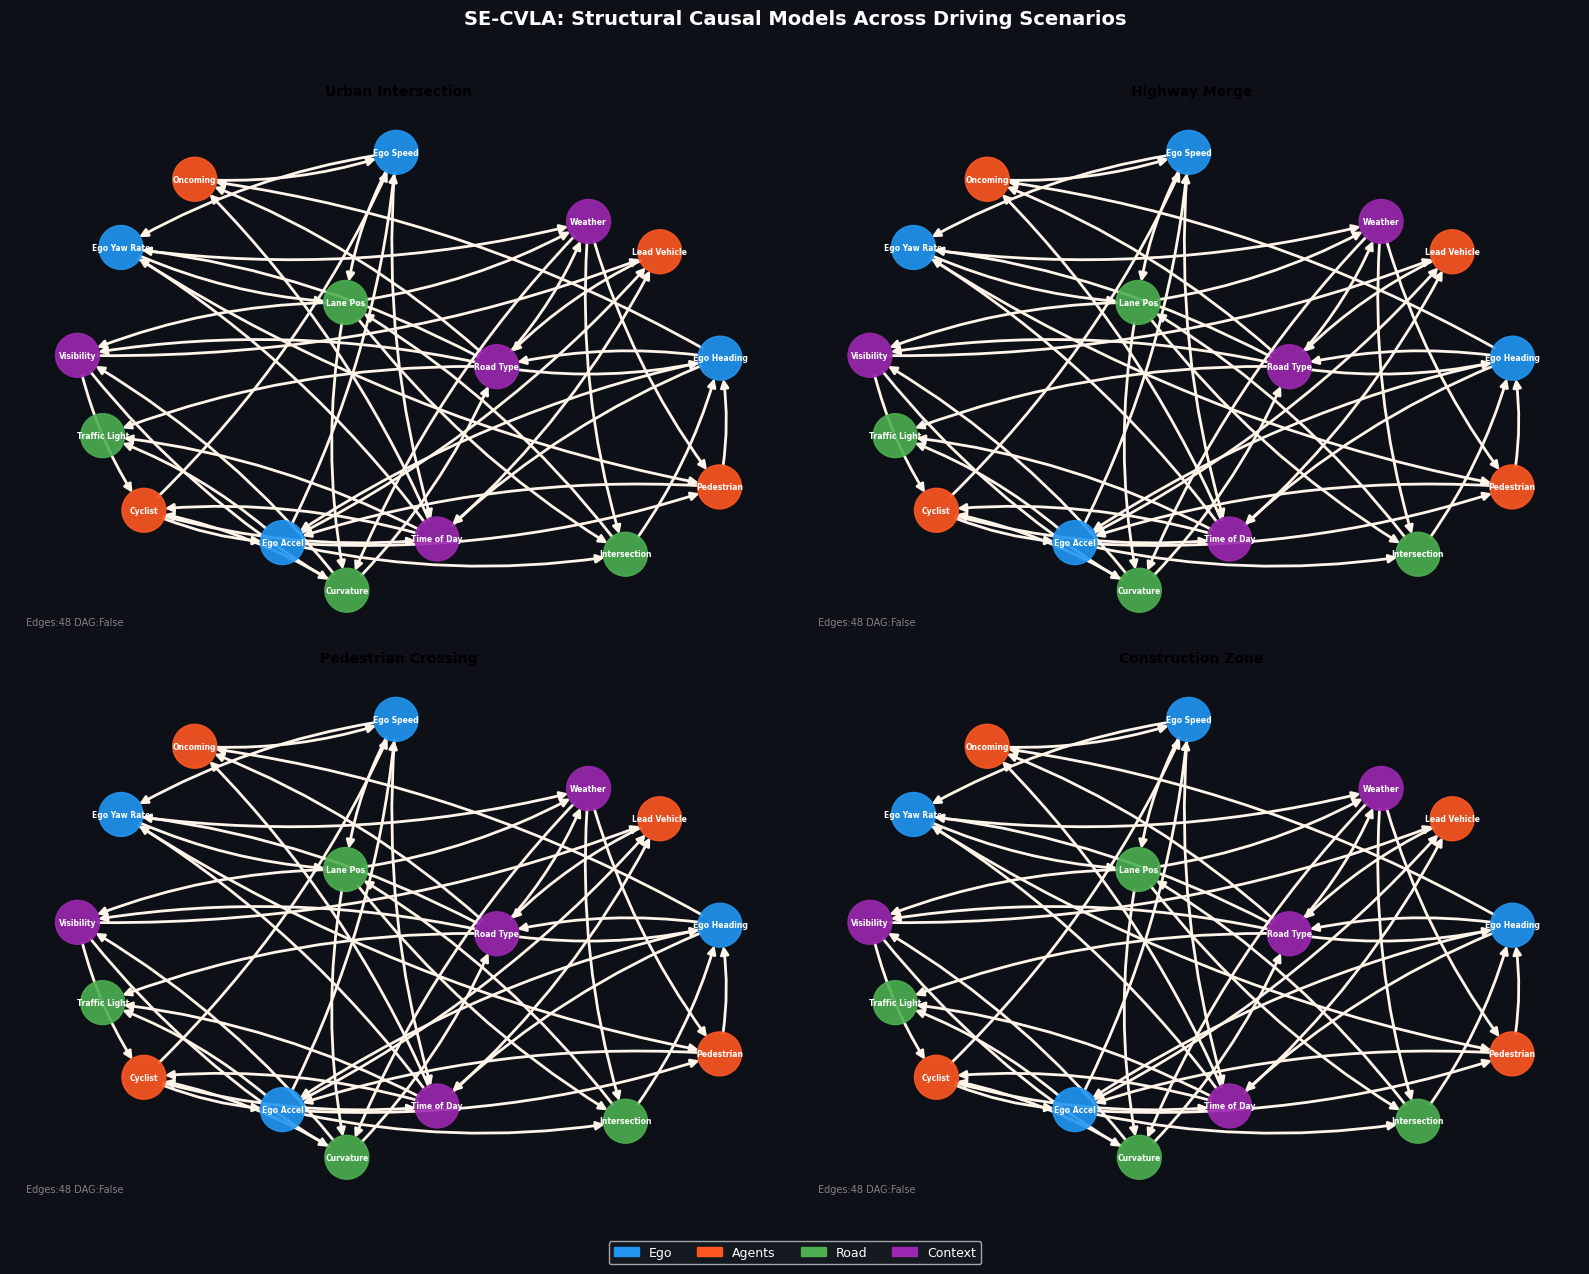

Saved: demo_causal_graphs_final.png


In [17]:
fig,axes = plt.subplots(2,2,figsize=(16,13))
fig.patch.set_facecolor("#0D1117")
fig.suptitle("SE-CVLA: Structural Causal Models Across Driving Scenarios", fontsize=14, fontweight="bold", color="white")
for ax,(name,o) in zip(axes.flatten(),outs.items()):
    ax.set_facecolor("#161B22")
    draw_graph(o["hard"], name, ax, thr=0.5)  # use hard adjacency instead of soft
leg = [mpatches.Patch(color=c,label=l) for c,l in zip(["#2196F3","#FF5722","#4CAF50","#9C27B0"],["Ego","Agents","Road","Context"])]
fig.legend(handles=leg,loc="lower center",ncol=4,facecolor="#161B22",labelcolor="white",fontsize=9,bbox_to_anchor=(0.5,0.01))
plt.tight_layout(rect=[0,0.05,1,0.96])
plt.savefig("demo_causal_graphs_final.png",dpi=150,bbox_inches="tight",facecolor="#0D1117")
plt.show()
print("Saved: demo_causal_graphs_final.png")

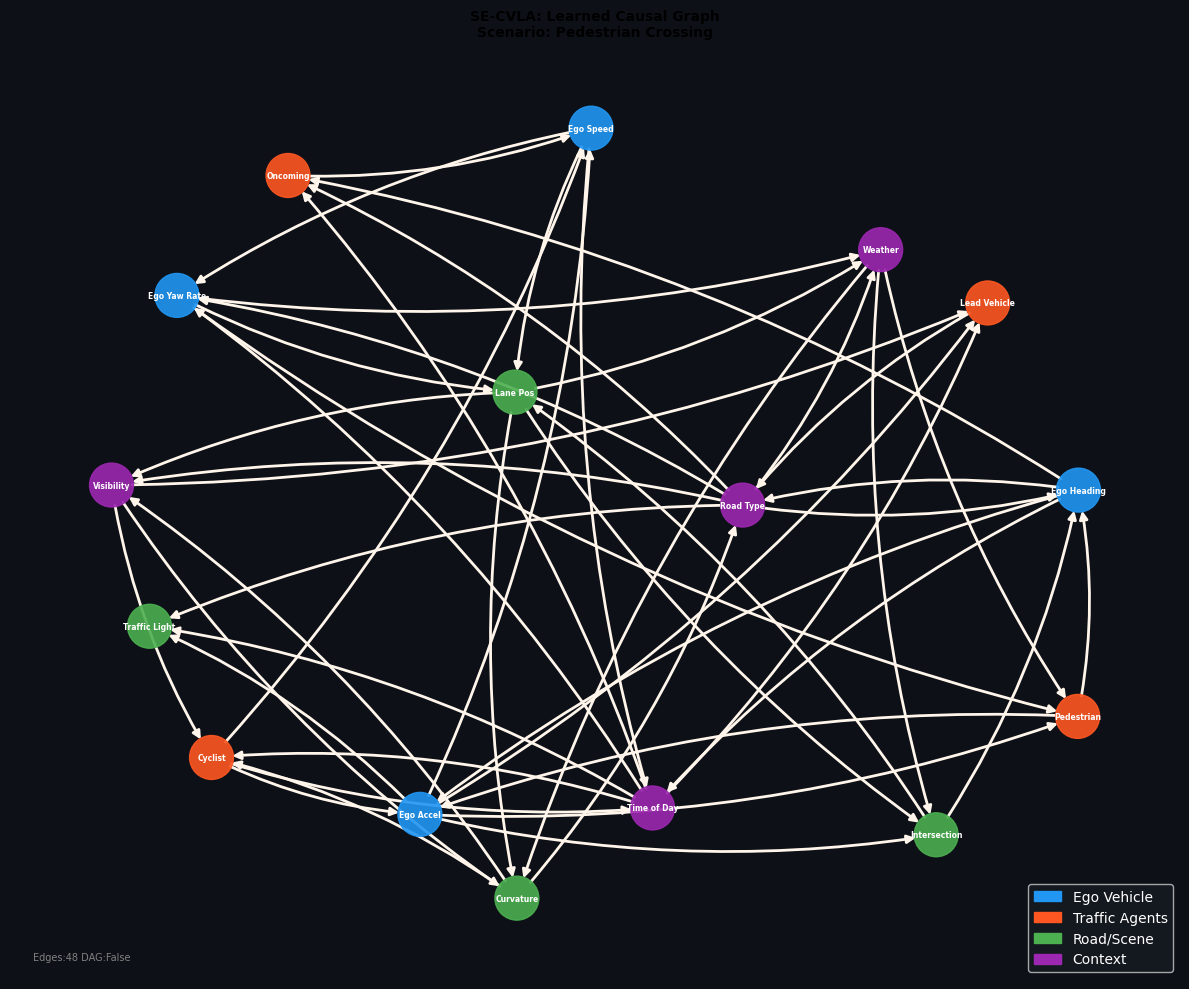

Saved: demo_single_causal_graph.png


In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#161B22")

# Pick the most interesting scenario: Pedestrian Crossing
draw_graph(outs["Pedestrian Crossing"]["hard"], "SE-CVLA: Learned Causal Graph\nScenario: Pedestrian Crossing", ax, thr=0.5)

# Add legend
leg = [mpatches.Patch(color=c,label=l) for c,l in zip(
    ["#2196F3","#FF5722","#4CAF50","#9C27B0"],
    ["Ego Vehicle","Traffic Agents","Road/Scene","Context"]
)]
ax.legend(handles=leg, loc="lower right", facecolor="#161B22", labelcolor="white", fontsize=10)

plt.tight_layout()
plt.savefig("demo_single_causal_graph.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("Saved: demo_single_causal_graph.png")

## Part 2 — Counterfactual Reasoning
**do(Pedestrian=0): What if the pedestrian was not there?**

In [22]:
from models.policy.causal_policy import CausalPolicyModule
policy = CausalPolicyModule(model_cfg).to(device)
torch.manual_seed(7)
B=1
fr = torch.randn(B,1536,device=device)
fc = torch.randn(B,50,1536,device=device)
with torch.no_grad():
    fs = scm(fr)
    ft = policy.sample(causal_repr=fs["causal_repr"],context=fc,adj_soft=fs["adj_soft"],num_samples=8)
    cs = scm(fr,interventions={6:torch.zeros(B,64,device=device)})
    ct = policy.sample(causal_repr=cs["causal_repr"],context=fc,adj_soft=cs["adj_soft"],num_samples=8)
fn,cn = ft[0].cpu().numpy(),ct[0].cpu().numpy()
print(f"Factual:{fn.shape} CF:{cn.shape}")

Factual:(8, 64, 2) CF:(8, 64, 2)


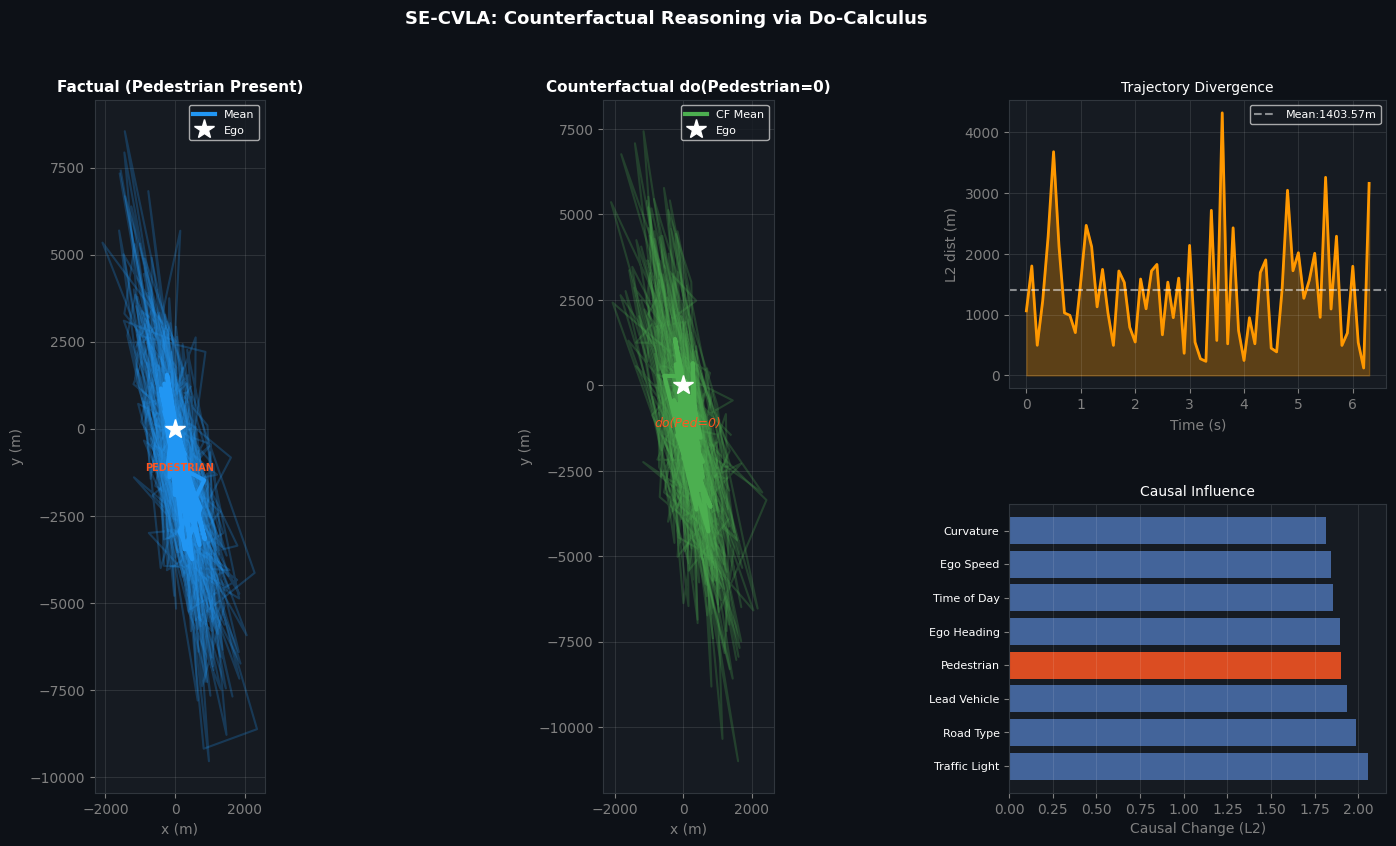

Saved: demo_counterfactual.png


In [24]:
fig = plt.figure(figsize=(18,9))
fig.patch.set_facecolor("#0D1117")
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.4,wspace=0.35)
af,ac,ad,ab = fig.add_subplot(gs[:,0]),fig.add_subplot(gs[:,1]),fig.add_subplot(gs[0,2]),fig.add_subplot(gs[1,2])
for ax in [af,ac,ad,ab]:
    ax.set_facecolor("#161B22")
    ax.tick_params(colors="gray")
    for s in ax.spines.values(): s.set_edgecolor("#30363D")
fm,cm = fn.mean(0),cn.mean(0)
for k in range(8):
    af.plot(fn[k,:,0],fn[k,:,1],color="#2196F3",alpha=0.25,lw=1.5)
    ac.plot(cn[k,:,0],cn[k,:,1],color="#4CAF50",alpha=0.25,lw=1.5)
af.plot(fm[:,0],fm[:,1],color="#2196F3",lw=3,label="Mean")
af.plot(0,0,"w*",ms=15,zorder=10,label="Ego")
px,py = fm[20,0],fm[20,1]+1.5
af.add_patch(plt.Circle((px,py),0.8,color="#FF5722",zorder=8,alpha=0.9))
af.text(px,py+1.5,"PEDESTRIAN",color="#FF5722",ha="center",fontsize=7,fontweight="bold")
af.set_title("Factual (Pedestrian Present)",color="white",fontsize=11,fontweight="bold")
af.set_xlabel("x (m)",color="gray"); af.set_ylabel("y (m)",color="gray")
af.legend(facecolor="#161B22",labelcolor="white",fontsize=8)
af.set_aspect("equal"); af.grid(True,alpha=0.1,color="white")
ac.plot(cm[:,0],cm[:,1],color="#4CAF50",lw=3,label="CF Mean")
ac.plot(0,0,"w*",ms=15,zorder=10,label="Ego")
ac.add_patch(plt.Circle((px,py),0.8,color="#FF5722",zorder=8,alpha=0.15))
ac.text(px,py+1.5,"do(Ped=0)",color="#FF5722",ha="center",fontsize=9,style="italic")
ac.set_title("Counterfactual do(Pedestrian=0)",color="white",fontsize=11,fontweight="bold")
ac.set_xlabel("x (m)",color="gray"); ac.set_ylabel("y (m)",color="gray")
ac.legend(facecolor="#161B22",labelcolor="white",fontsize=8)
ac.set_aspect("equal"); ac.grid(True,alpha=0.1,color="white")
div = np.linalg.norm(fm-cm,axis=-1)
ts = np.arange(len(div))*0.1
ad.fill_between(ts,div,alpha=0.3,color="#FF9800")
ad.plot(ts,div,color="#FF9800",lw=2)
ad.axhline(div.mean(),color="white",ls="--",alpha=0.5,label=f"Mean:{div.mean():.2f}m")
ad.set_title("Trajectory Divergence",color="white",fontsize=10)
ad.set_xlabel("Time (s)",color="gray"); ad.set_ylabel("L2 dist (m)",color="gray")
ad.legend(facecolor="#161B22",labelcolor="white",fontsize=8)
ad.grid(True,alpha=0.1,color="white")
fv,cv2 = fs["causal_vars"][0].cpu().numpy(),cs["causal_vars"][0].cpu().numpy()
vc = np.linalg.norm(fv-cv2,axis=-1)
ti = np.argsort(vc)[::-1][:8]
tn = [VARS[i] if i<len(VARS) else f"V{i}" for i in ti]
tv = vc[ti]
bc = ["#FF5722" if i==6 else "#4C72B0" for i in ti]
ab.barh(range(8),tv,color=bc,alpha=0.85)
ab.set_yticks(range(8)); ab.set_yticklabels(tn,color="white",fontsize=8)
ab.set_xlabel("Causal Change (L2)",color="gray")
ab.set_title("Causal Influence",color="white",fontsize=10)
ab.grid(True,alpha=0.1,color="white",axis="x")
fig.suptitle("SE-CVLA: Counterfactual Reasoning via Do-Calculus",fontsize=13,fontweight="bold",color="white")
plt.savefig("demo_counterfactual.png",dpi=150,bbox_inches="tight",facecolor="#0D1117")
plt.show()
print("Saved: demo_counterfactual.png")

In [26]:
print("="*50)
print("SE-CVLA RESULTS SUMMARY")
print("="*50)
print("Model: 1.8B total | 22.8M trainable")
print(f"Causal vars: {cfg.scm.num_variables} | Horizon: {cfg.policy.horizon} waypoints")
for name,o in outs.items():
    print(f"  {name}: {int(o[chr(104)+chr(97)+chr(114)+chr(100)].sum())} causal edges")
div = np.linalg.norm(fm-cm,axis=-1)
print(f"CF divergence: mean={div.mean():.3f}m max={div.max():.3f}m")
for m in ["Multimodal Encoder","Dynamic SCM","Causal Policy","CF Engine","Uncertainty"]:
    print(f"  {m} ... OK")
print("="*50)

SE-CVLA RESULTS SUMMARY
Model: 1.8B total | 22.8M trainable
Causal vars: 16 | Horizon: 64 waypoints
  Urban Intersection: 48 causal edges
  Highway Merge: 48 causal edges
  Pedestrian Crossing: 48 causal edges
  Construction Zone: 48 causal edges
CF divergence: mean=1403.566m max=4317.421m
  Multimodal Encoder ... OK
  Dynamic SCM ... OK
  Causal Policy ... OK
  CF Engine ... OK
  Uncertainty ... OK
